In [49]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy import asarray

In [50]:
orig_4_4 = np.array([[1, 3, 5,3, 6 ], [6,2,0,8, 6], [4,6,1,4, 9], [2,8,0,3, 0], [2,8,0,3, 1]])
print(orig_4_4)

[[1 3 5 3 6]
 [6 2 0 8 6]
 [4 6 1 4 9]
 [2 8 0 3 0]
 [2 8 0 3 1]]


In [51]:
def maxpool(x_in):
  x_out = np.zeros((
    int(np.ceil(x_in.shape[0] / 2)),
    int(np.ceil(x_in.shape[1] / 2)),
  ))
  
  kernel_size = 2
  stride = 2
  
  if x_in.shape[0] % 2 != 0:
    x_in = np.hstack((
      x_in, 
      np.full(x_in.shape[0], 0).reshape(x_in.shape[0], 1)
    ))
    
    x_in = np.vstack((
      x_in,
      np.full(x_in.shape[1], 0)
    ))  
  
  for i in range(x_out.shape[0]):
    for j in range(x_out.shape[1]):
      
      temp_window = []
      
      for kernel_i in range(kernel_size):
        for kernel_j in range(kernel_size):
          x_in_i = i * stride + kernel_i
          x_in_j = j * stride + kernel_j
          
          if 0 <= x_in_i < x_in.shape[0] and 0 <= x_in_j < x_in.shape[1]:       
            temp_window.append(x_in[x_in_i, x_in_j])
      
      x_out[i, j] = max(temp_window)
  
  return x_out

In [52]:
print("Original:")
print(orig_4_4)
print("Subsampled:")
print(maxpool(orig_4_4))

Original:
[[1 3 5 3 6]
 [6 2 0 8 6]
 [4 6 1 4 9]
 [2 8 0 3 0]
 [2 8 0 3 1]]
Subsampled:
[[6. 8. 6.]
 [8. 4. 9.]
 [8. 3. 1.]]


In [53]:
image = Image.open("./image.png")

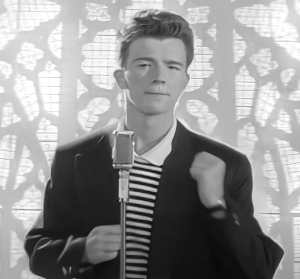

In [54]:
image

In [55]:
data = asarray(image)
data = data[:, :, 0]
data.shape

(279, 300)

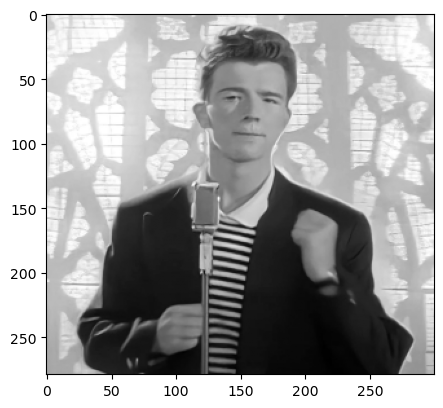

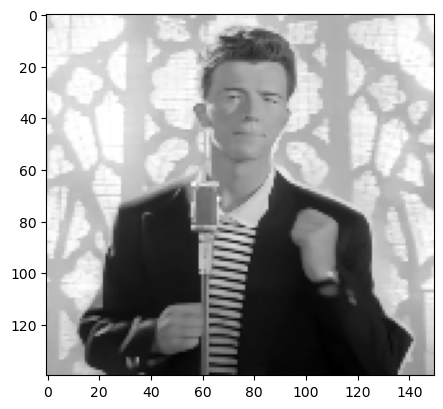

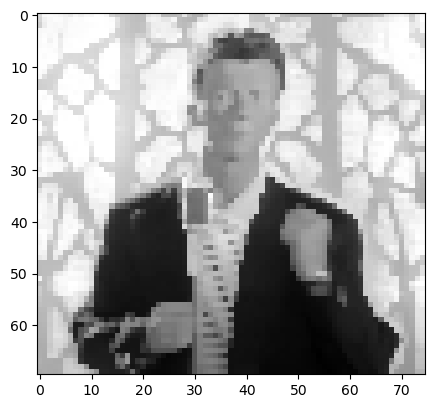

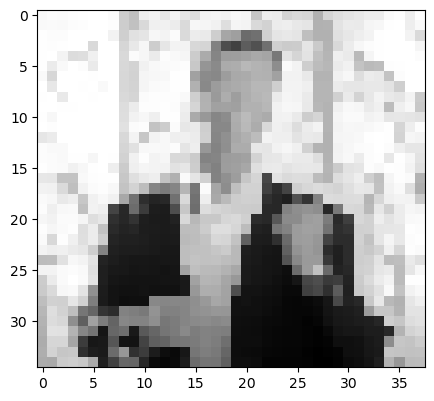

In [56]:
data_subsample = maxpool(data);

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_subsample, cmap='gray')
plt.show()

data_subsample2 = maxpool(data_subsample)
plt.figure(figsize=(5,5))
plt.imshow(data_subsample2, cmap='gray')
plt.show()

data_subsample3 = maxpool(data_subsample2)
plt.figure(figsize=(5,5))
plt.imshow(data_subsample3, cmap='gray')
plt.show()

In [57]:
def meanpool(x_in):
  x_out = np.zeros((
    int(np.ceil(x_in.shape[0] / 2)),
    int(np.ceil(x_in.shape[1] / 2)),
  ))
  
  kernel_size = 2
  stride = 2
  
  if x_in.shape[0] % 2 != 0:
    x_in = np.hstack((
      x_in, 
      np.full(x_in.shape[0], 0).reshape(x_in.shape[0], 1)
    ))
    
    x_in = np.vstack((
      x_in,
      np.full(x_in.shape[1], 0)
    ))  
  
  for i in range(x_out.shape[0]):
    for j in range(x_out.shape[1]):
      
      temp_window = []
      
      for kernel_i in range(kernel_size):
        for kernel_j in range(kernel_size):
          x_in_i = i * stride + kernel_i
          x_in_j = j * stride + kernel_j
          
          if 0 <= x_in_i < x_in.shape[0] and 0 <= x_in_j < x_in.shape[1]:       
            temp_window.append(x_in[x_in_i, x_in_j])
      
      x_out[i, j] = np.ceil(sum(temp_window) / len(temp_window))
  
  return x_out

In [58]:

print("Original:")
print(orig_4_4)
print("Meanpooled:")
print(meanpool(orig_4_4))

Original:
[[1 3 5 3 6]
 [6 2 0 8 6]
 [4 6 1 4 9]
 [2 8 0 3 0]
 [2 8 0 3 1]]
Meanpooled:
[[3. 4. 3.]
 [5. 2. 3.]
 [3. 1. 1.]]


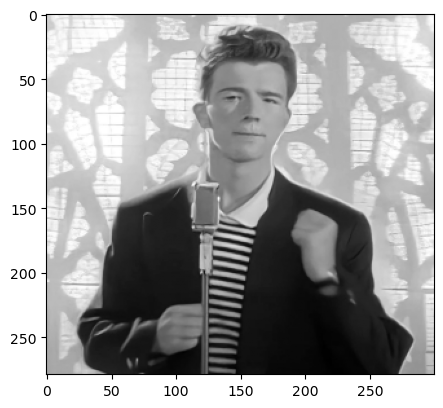

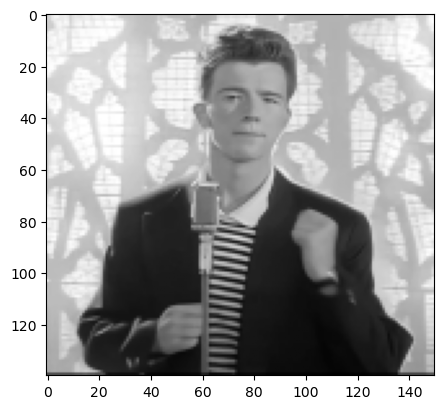

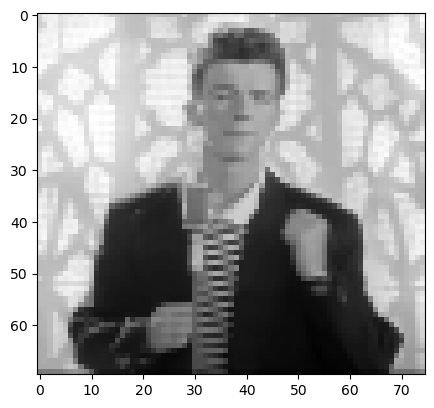

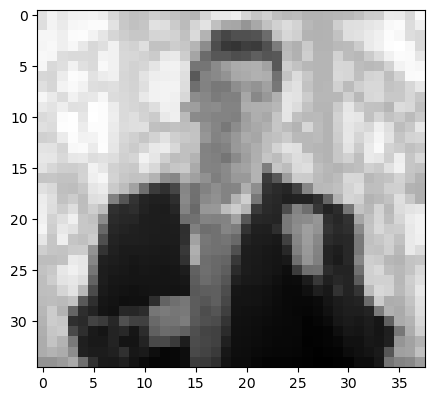

In [59]:
data_meanpool = meanpool(data);

plt.figure(figsize=(5,5))
plt.imshow(data, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_meanpool, cmap='gray')
plt.show()

data_meanpool2 = meanpool(data_meanpool)
plt.figure(figsize=(5,5))
plt.imshow(data_meanpool2, cmap='gray')
plt.show()

data_meanpool3 = meanpool(data_meanpool2)
plt.figure(figsize=(5,5))
plt.imshow(data_meanpool3, cmap='gray')
plt.show()

In [64]:
# Define 2 by 2 original patch
orig_2_2 = np.array([[6, 8, 4], [8,4, 1], [8,4, 1]])
print(orig_2_2)

[[6 8 4]
 [8 4 1]
 [8 4 1]]


In [62]:
def duplicate(x_in):
  x_out = np.zeros((
    x_in.shape[0] * 2,
    x_in.shape[1] * 2
  ))
  
  kernel_size = 2
  stride = 2
  
  for x_in_i in range(x_in.shape[0]):
    for x_in_j in range(x_in.shape[1]):
      
      value = x_in[x_in_i, x_in_j]
      
      for kernel_i in range(kernel_size):
        for kernel_j in range(kernel_size):
          x_out_i = x_in_i * stride + kernel_i
          x_out_j = x_in_j * stride + kernel_j
          
          if(0 <= x_out_i < x_out.shape[0] and 0 <= x_out_j < x_out.shape[1]):
            x_out[x_out_i, x_out_j] = value
          
  return x_out
      

In [65]:
print("Original:")
print(orig_2_2)
print("Duplicated:")
print(duplicate(orig_2_2))

Original:
[[6 8 4]
 [8 4 1]
 [8 4 1]]
Duplicated:
[[6. 6. 8. 8. 4. 4.]
 [6. 6. 8. 8. 4. 4.]
 [8. 8. 4. 4. 1. 1.]
 [8. 8. 4. 4. 1. 1.]
 [8. 8. 4. 4. 1. 1.]
 [8. 8. 4. 4. 1. 1.]]


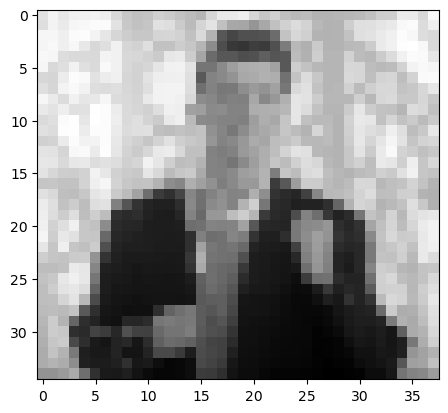

In [69]:
plt.imshow(data_meanpool3, cmap="gray")

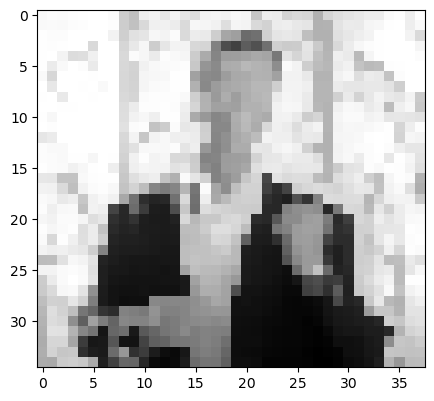

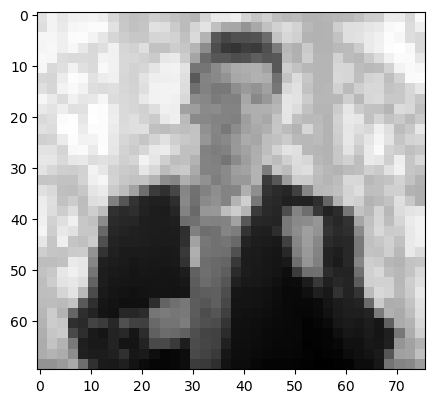

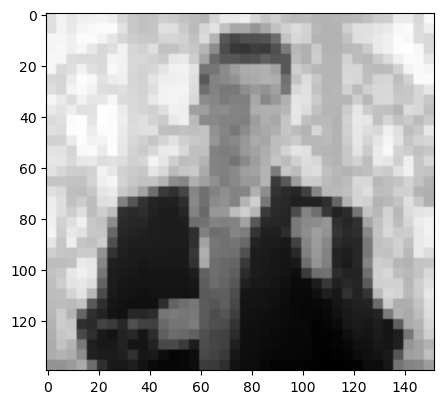

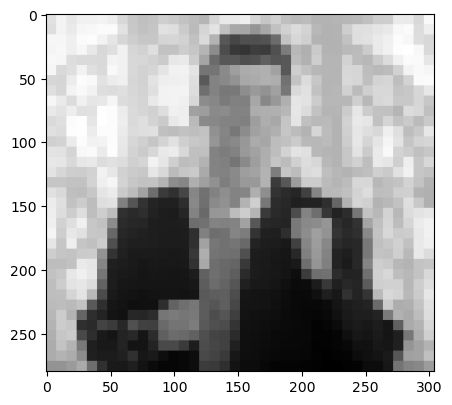

In [70]:
data_duplicate = duplicate(data_meanpool3)

plt.figure(figsize=(5,5))
plt.imshow(data_subsample3, cmap='gray')
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(data_duplicate, cmap='gray')
plt.show()

data_duplicate2 = duplicate(data_duplicate)
plt.figure(figsize=(5,5))
plt.imshow(data_duplicate2, cmap='gray')
plt.show()

data_duplicate3 = duplicate(data_duplicate2)
plt.figure(figsize=(5,5))
plt.imshow(data_duplicate3, cmap='gray')
plt.show()